# Model evaluation, Error Analysis và Negative threshold

Notebook đánh giá mô hình Stacking đã bàn giao trên **final test 1.683 mẫu**. Không huấn luyện lại model. Chính sách được nhóm yêu cầu là: nếu `P(Negative) >= 0.30` thì ưu tiên nhãn Negative; các mẫu còn lại giữ nhãn mặc định của model.

> Lưu ý phương pháp: final test được dùng để báo cáo và phân tích độ nhạy, không dùng để tuyên bố ngưỡng 0.30 là ngưỡng tối ưu tổng quát. Muốn tối ưu ngưỡng chính thức cần validation/OOF riêng.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from src.app_services import NEGATIVE_THRESHOLD, apply_negative_threshold

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
EVALUATION_DIR = PROJECT_ROOT / 'reports' / 'evaluation'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
LABELS = ['Negative', 'Neutral', 'Positive']
print(f'Negative policy threshold: {NEGATIVE_THRESHOLD:.0%}')

Negative policy threshold: 30%


In [2]:
model = joblib.load(PROJECT_ROOT / 'models' / 'best_sentiment_model.joblib')
artifact = joblib.load(PROJECT_ROOT / 'models' / 'train_test_features.joblib')
reviews = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'reviews_cleaned.csv')

X_test = artifact['X_test']
y_test = np.asarray(artifact['y_test']).astype(str)
test_indices = np.asarray(artifact['test_indices'])
test_reviews = reviews.loc[test_indices].reset_index(names='source_index')
assert np.array_equal(test_reviews['sentiment'].astype(str).to_numpy(), y_test)

classes = np.asarray(model.classes_).astype(str)
probabilities = np.asarray(model.predict_proba(X_test))
baseline_prediction = np.asarray(model.predict(X_test)).astype(str)
policy_prediction = apply_negative_threshold(
    baseline_prediction, probabilities, classes, NEGATIVE_THRESHOLD
)
negative_index = int(np.where(classes == 'Negative')[0][0])
import json, hashlib
snapshot = {
    'labels': LABELS, 'test_count': len(y_test),
    'threshold': NEGATIVE_THRESHOLD,
    'baseline_matrix': confusion_matrix(y_test, baseline_prediction, labels=LABELS).tolist(),
    'policy_matrix': confusion_matrix(y_test, policy_prediction, labels=LABELS).tolist(),
    'model_sha256': hashlib.sha256((PROJECT_ROOT / 'models' / 'best_sentiment_model.joblib').read_bytes()).hexdigest(),
    'split_sha256': hashlib.sha256((PROJECT_ROOT / 'models' / 'train_test_features.joblib').read_bytes()).hexdigest(),
    'method': 'Post-hoc sensitivity on the previously evaluated final test; not independent validation.',
}
(EVALUATION_DIR / 'evaluation_snapshot.json').write_text(json.dumps(snapshot, indent=2), encoding='utf-8')
print(f'Final test: {len(y_test):,} mẫu | classes={classes.tolist()}')

Final test: 1,683 mẫu | classes=['Negative', 'Neutral', 'Positive']


## 1. Đánh giá baseline và chính sách ngưỡng 30%

In [3]:
def metric_row(name, prediction):
    report = classification_report(
        y_test, prediction, labels=LABELS, output_dict=True, zero_division=0
    )
    return {
        'Phương án': name,
        'Accuracy': accuracy_score(y_test, prediction),
        'Macro F1': f1_score(y_test, prediction, average='macro'),
        'Weighted F1': f1_score(y_test, prediction, average='weighted'),
        'Negative Precision': report['Negative']['precision'],
        'Negative Recall': report['Negative']['recall'],
        'Negative F1': report['Negative']['f1-score'],
        'Số dự đoán Negative': int((prediction == 'Negative').sum()),
    }

comparison = pd.DataFrame([
    metric_row('Baseline / argmax (0.50)', baseline_prediction),
    metric_row(f'Negative threshold {NEGATIVE_THRESHOLD:.2f}', policy_prediction),
])
comparison.to_csv(EVALUATION_DIR / 'baseline_vs_negative_threshold.csv', index=False)
display(comparison.style.format({
    column: '{:.4f}' for column in comparison.columns if column not in ['Phương án', 'Số dự đoán Negative']
}))
print('Classification report — threshold 0.30')
print(classification_report(y_test, policy_prediction, labels=LABELS, digits=4, zero_division=0))

,Phương án,Accuracy,Macro F1,Weighted F1,Negative Precision,Negative Recall,Negative F1,Số dự đoán Negative
0,Baseline / argmax (0.50),0.7766,0.5475,0.7539,0.5357,0.2632,0.3529,56
1,Negative threshold 0.30,0.7730,0.5507,0.7505,0.4444,0.3509,0.3922,90


Classification report — threshold 0.30
              precision    recall  f1-score   support

    Negative     0.4444    0.3509    0.3922       114
     Neutral     0.4975    0.3049    0.3781       328
    Positive     0.8341    0.9355    0.8819      1241

    accuracy                         0.7730      1683
   macro avg     0.5920    0.5304    0.5507      1683
weighted avg     0.7421    0.7730    0.7505      1683



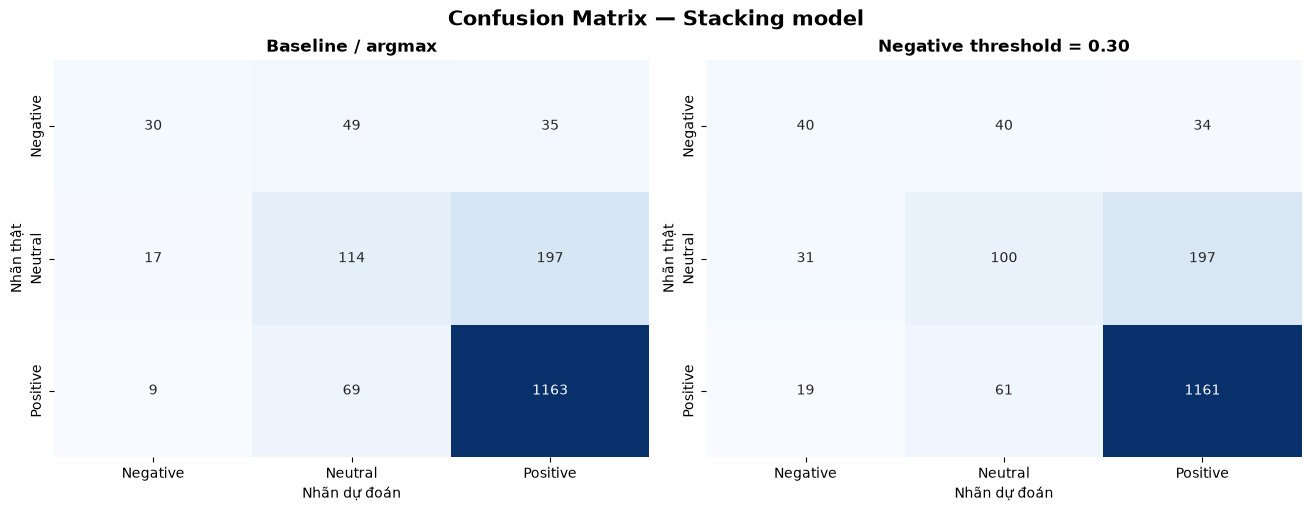

reports\figures\stacking_confusion_matrix_threshold_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for axis, title, prediction in [
    (axes[0], 'Baseline / argmax', baseline_prediction),
    (axes[1], 'Negative threshold = 0.30', policy_prediction),
]:
    matrix = confusion_matrix(y_test, prediction, labels=LABELS)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis,
                xticklabels=LABELS, yticklabels=LABELS)
    axis.set_title(title, fontweight='bold')
    axis.set_xlabel('Nhãn dự đoán')
    axis.set_ylabel('Nhãn thật')
fig.suptitle('Confusion Matrix — Stacking model', fontsize=15, fontweight='bold')
figure_path = FIGURES_DIR / 'stacking_confusion_matrix_threshold_comparison.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(figure_path.relative_to(PROJECT_ROOT))

## 2. Phân tích độ nhạy theo ngưỡng

Bảng này kiểm chứng tác động của ngưỡng, không dùng để chọn ngưỡng tối ưu trên final test.

,Accuracy,Macro F1,Weighted F1,Negative Precision,Negative Recall,Negative F1,Số dự đoán Negative,Threshold
4,0.7683,0.5545,0.7439,0.3793,0.5789,0.4583,174.0000,0.1800
5,0.7695,0.5537,0.7453,0.3896,0.5263,0.4478,154.0000,0.2000
10,0.7730,0.5507,0.7505,0.4444,0.3509,0.3922,90.0000,0.3000
20,0.7766,0.5475,0.7539,0.5357,0.2632,0.3529,56.0000,0.5000


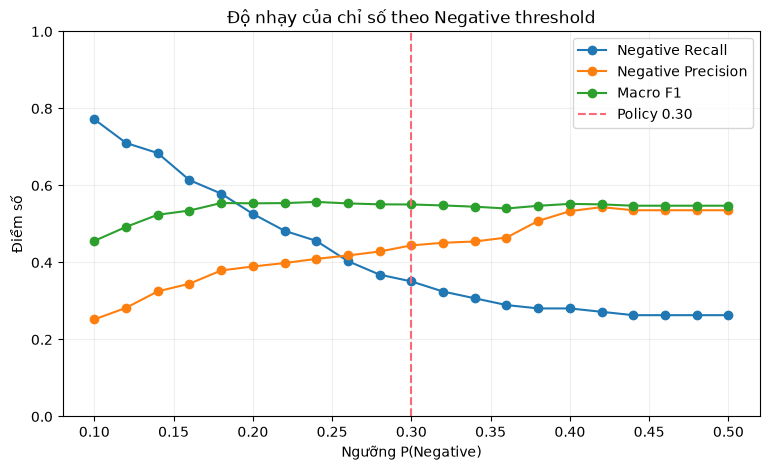

In [5]:
threshold_rows = []
for threshold in np.round(np.arange(0.10, 0.51, 0.02), 2):
    prediction = apply_negative_threshold(
        baseline_prediction, probabilities, classes, float(threshold)
    )
    row = metric_row(f'{threshold:.2f}', prediction)
    row['Threshold'] = float(threshold)
    threshold_rows.append(row)
threshold_metrics = pd.DataFrame(threshold_rows).drop(columns='Phương án')
threshold_metrics.to_csv(EVALUATION_DIR / 'negative_threshold_sensitivity.csv', index=False)
display(threshold_metrics[threshold_metrics['Threshold'].isin([0.18, 0.20, 0.30, 0.50])].style.format('{:.4f}'))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_metrics['Threshold'], threshold_metrics['Negative Recall'], marker='o', label='Negative Recall')
ax.plot(threshold_metrics['Threshold'], threshold_metrics['Negative Precision'], marker='o', label='Negative Precision')
ax.plot(threshold_metrics['Threshold'], threshold_metrics['Macro F1'], marker='o', label='Macro F1')
ax.axvline(NEGATIVE_THRESHOLD, color='#ff6677', linestyle='--', label='Policy 0.30')
ax.set(xlabel='Ngưỡng P(Negative)', ylabel='Điểm số', ylim=(0, 1), title='Độ nhạy của chỉ số theo Negative threshold')
ax.grid(alpha=.2)
ax.legend()
threshold_figure = FIGURES_DIR / 'negative_threshold_sensitivity.png'
fig.savefig(threshold_figure, dpi=300, bbox_inches='tight')
plt.show()

## 3. Error Analysis trên các dự đoán sai

Mỗi mẫu dưới đây là dữ liệu thật trong final test. `Nhóm tín hiệu` là phân loại heuristic hỗ trợ đọc lỗi, không phải nhãn ground truth mới.

In [6]:
analysis = test_reviews[['source_index', 'Company Name', 'Rating', 'raw_review_text']].copy()
analysis['Nhãn thật'] = y_test
analysis['Baseline'] = baseline_prediction
analysis['Threshold 0.30'] = policy_prediction
analysis['P(Negative)'] = probabilities[:, negative_index]
analysis['Cặp nhầm'] = analysis['Nhãn thật'] + ' → ' + analysis['Threshold 0.30']

def signal_group(text):
    value = str(text).lower()
    if len(value.split()) <= 8:
        return 'Câu ngắn / thiếu ngữ cảnh'
    if any(token in value for token in ['không', 'chưa', 'chẳng', 'khó', 'thiếu']):
        return 'Phủ định hoặc sắc thái đảo chiều'
    if any(token in value for token in ['nhưng', 'tuy nhiên', 'mặc dù', 'đổi lại', 'bù lại']):
        return 'Khen và chê trong cùng review'
    if any(token in value for token in ['ot', 'overtime', 'deadline', 'task', 'project', 'benefit']):
        return 'Từ lóng / ngữ cảnh ngành IT'
    return 'Sắc thái hoặc ngữ cảnh chưa rõ'

errors = analysis[analysis['Nhãn thật'] != analysis['Threshold 0.30']].copy()
errors['Nhóm tín hiệu'] = errors['raw_review_text'].map(signal_group)
errors['Độ chắc chắn lỗi'] = np.where(
    errors['Threshold 0.30'].eq('Negative'),
    errors['P(Negative)'],
    1 - errors['P(Negative)'],
)
errors = errors.sort_values(['Cặp nhầm', 'Độ chắc chắn lỗi'], ascending=[True, False])
samples = errors.groupby('Cặp nhầm', group_keys=False).head(3)
if len(samples) < 15:
    extra = errors.loc[~errors.index.isin(samples.index)].head(15 - len(samples))
    samples = pd.concat([samples, extra])
samples = samples.head(15)

errors.to_csv(EVALUATION_DIR / 'all_policy_errors.csv', index=False, encoding='utf-8-sig')
samples.to_csv(EVALUATION_DIR / 'error_analysis_15_samples.csv', index=False, encoding='utf-8-sig')
display(samples[['source_index', 'Company Name', 'Rating', 'Nhãn thật', 'Threshold 0.30', 'P(Negative)', 'Cặp nhầm', 'Nhóm tín hiệu', 'raw_review_text']])
display(pd.crosstab(errors['Nhãn thật'], errors['Threshold 0.30'], margins=True))

,source_index,Company Name,Rating,Nhãn thật,Threshold 0.30,P(Negative),Cặp nhầm,Nhóm tín hiệu,raw_review_text
1573,2642,FPT Software,2,Negative,Neutral,0.057876,Negative → Neutral,Phủ định hoặc sắc thái đảo chiều,"Dành cho Fresher . Công ty đông, đa dạng.\r\nN..."
82,2564,FPT Software,2,Negative,Neutral,0.091548,Negative → Neutral,Phủ định hoặc sắc thái đảo chiều,Môi trường làm việc dành cho fresher . không g...
1206,3144,FPT Software,2,Negative,Neutral,0.093849,Negative → Neutral,Phủ định hoặc sắc thái đảo chiều,Môi trường tốt cho sinh viên mới ra trường . -...
1160,2668,FPT Software,2,Negative,Positive,0.002829,Negative → Positive,Từ lóng / ngữ cảnh ngành IT,Môi trường làm việc năng động . Môi trường năn...
1612,3094,FPT Software,2,Negative,Positive,0.003553,Negative → Positive,Từ lóng / ngữ cảnh ngành IT,Lương hơi thấp và đôi khi OT hơi nhiều . Môi t...
1328,5220,NAB Innovation Centre Vietnam,2,Negative,Positive,0.008083,Negative → Positive,Từ lóng / ngữ cảnh ngành IT,"Good views, good benefits, just quite bad mana..."
830,8096,VNG Corporation,3,Neutral,Negative,0.854224,Neutral → Negative,Phủ định hoặc sắc thái đảo chiều,"Quản lí kém cỏi, văn hóa công ty khá tệ, lương..."
178,950,ekino Vietnam,3,Neutral,Negative,0.804596,Neutral → Negative,Phủ định hoặc sắc thái đảo chiều,Chỉ phù hợp cho các PHP developer . Đa số là i...
1584,3791,Hitachi Digital Services,3,Neutral,Negative,0.738329,Neutral → Negative,Phủ định hoặc sắc thái đảo chiều,CTY phù hợp với những bạn mới ra trường . HR đ...
275,4736,LG CNS Việt Nam,3,Neutral,Positive,0.001684,Neutral → Positive,Phủ định hoặc sắc thái đảo chiều,Working environment is very good!! . Công ty c...


Threshold 0.30,Negative,Neutral,Positive,All
Nhãn thật,,,,
Negative,0,40,34,74
Neutral,31,0,197,228
Positive,19,61,0,80
All,50,101,231,382


## 4. Kết luận

- Baseline bỏ sót phần lớn lớp Negative do dữ liệu mất cân bằng và ranh giới giữa review 1–2 sao với nội dung pha trộn.
- Policy 0.30 tăng Recall Negative nhưng cũng tăng false positive; kết quả thực đo phải được dùng thay cho con số dự kiến.
- Các lỗi Neutral → Positive và Negative → Neutral/Positive cho thấy rating-derived weak label và nội dung vừa khen vừa chê là hai nguồn nhiễu quan trọng.
- Web Demo dùng cùng policy 0.30 để kết quả triển khai nhất quán với notebook.